<a href="https://colab.research.google.com/github/lenagromova/Praktika2/blob/main/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%22RNN_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **RNN/LSTM**

Цель семинара: получить практический опыт работы с RNN (LSTM) в PyTorch на задачах генерации последовательностей

Мы разберем полный пайплайн разработки от препроцессинга данных до обучения и экспериментов с гиперпараметрами

Кстати, что мы называем **пайплайном**?

В Google Colab (рекомендуется активировать GPU: `Среда выполнения → Сменить среду выполнения → T4 GPU`)

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import reuters

## **ЧАСТЬ 1: ДЕМО**
*   **Задача модели:** предсказание случайного временного ряда (синусоида)
*   **Цель демонстрации:** показать полный и минимальный рабочий пайплайн RNN на задаче, связанной с обработкой данных, передающих изменения во времени
*   **План:**
    1.  Подготовка последовательностей (sequences)
    2.  Архитектура `nn.LSTM`
    3.  Обучение модели
    4.  Получение метрик оценки
    5.  Визуализация и интерпретация результата

### 1. ГЕНЕРАЦИЯ И ПОДГОТОВКА ДАННЫХ

In [10]:
def generate_sine_wave(seq_length=1000, periods=5):
    """Генерация синусоиды."""
    x = np.linspace(0, periods * 2 * np.pi, seq_length)
    y = np.sin(x)
    return y

# Генерация данных
data = generate_sine_wave()
print(f"Длина временного ряда: {len(data)}")

Длина временного ряда: 1000


In [11]:
# Параметры последовательностей
SEQ_LEN = 50  # Длина входной последовательности для предсказания
BATCH_SIZE = 16

In [12]:
def create_sequences(data, seq_len):
    """Создание пар (входная последовательность, целевое значение)."""
    sequences = []
    targets = []
    for i in range(len(data) - seq_len - 1):
        seq = data[i:i + seq_len]
        target = data[i + seq_len]
        sequences.append(seq)
        targets.append(target)
    return np.array(sequences), np.array(targets)

In [13]:
# Создание последовательностей
X, y = create_sequences(data, SEQ_LEN)
print(f"Форма X (последовательности): {X.shape}")
print(f"Форма y (цели): {y.shape}")

Форма X (последовательности): (949, 50)
Форма y (цели): (949,)


In [14]:
# Преобразование в тензоры PyTorch и добавление размерности для признаков
X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)  # [примеры, SEQ_LEN, 1]
y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)  # [примеры, 1]
print(f"Форма X (тензор): {X.shape}")
print(f"Форма y (тензор): {y.shape}")

Форма X (тензор): torch.Size([949, 50, 1])
Форма y (тензор): torch.Size([949, 1])


In [15]:
# Разделение на обучающую и тестовую выборки
split_idx = int(0.8 * len(X))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

In [16]:
### 2. ОПРЕДЕЛЕНИЕ МОДЕЛИ LSTM
class SineLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True  # формат [batch, seq_len, features]
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Инициализация скрытого состояния и состояния ячейки
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)

        # Прямой проход через LSTM
        out, _ = self.lstm(x, (h0, c0))

        # Берем только последний выход последовательности для предсказания
        out = self.fc(out[:, -1, :])
        return out

In [17]:
# Инициализация модели
model = SineLSTM()
print(f"Модель:\n{model}")

Модель:
SineLSTM(
  (lstm): LSTM(1, 50, num_layers=2, batch_first=True)
  (fc): Linear(in_features=50, out_features=1, bias=True)
)


### 3. ОБУЧЕНИЕ МОДЕЛИ

In [18]:
# Гиперпараметры
EPOCHS = 20
LEARNING_RATE = 0.01

# Функция потерь и оптимизатор
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Тренировочный цикл
train_losses = []
test_losses = []

for epoch in range(EPOCHS):
    model.train()

    # Прямой проход
    predictions = model(X_train)
    loss = criterion(predictions, y_train)

    # Обратное распространение
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    # Оценка на тестовой выборке
    model.eval()
    with torch.no_grad():
        test_predictions = model(X_test)
        test_loss = criterion(test_predictions, y_test)
        test_losses.append(test_loss.item())

    if (epoch + 1) % 5 == 0:
        print(f'Эпоха [{epoch+1}/{EPOCHS}], '
              f'Ошибка обучения: {loss.item():.6f}, '
              f'Ошибка теста: {test_loss.item():.6f}')

Эпоха [5/20], Ошибка обучения: 0.706900, Ошибка теста: 0.117746
Эпоха [10/20], Ошибка обучения: 0.193957, Ошибка теста: 0.200174
Эпоха [15/20], Ошибка обучения: 0.053142, Ошибка теста: 0.044525
Эпоха [20/20], Ошибка обучения: 0.061357, Ошибка теста: 0.043203


### 4. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ

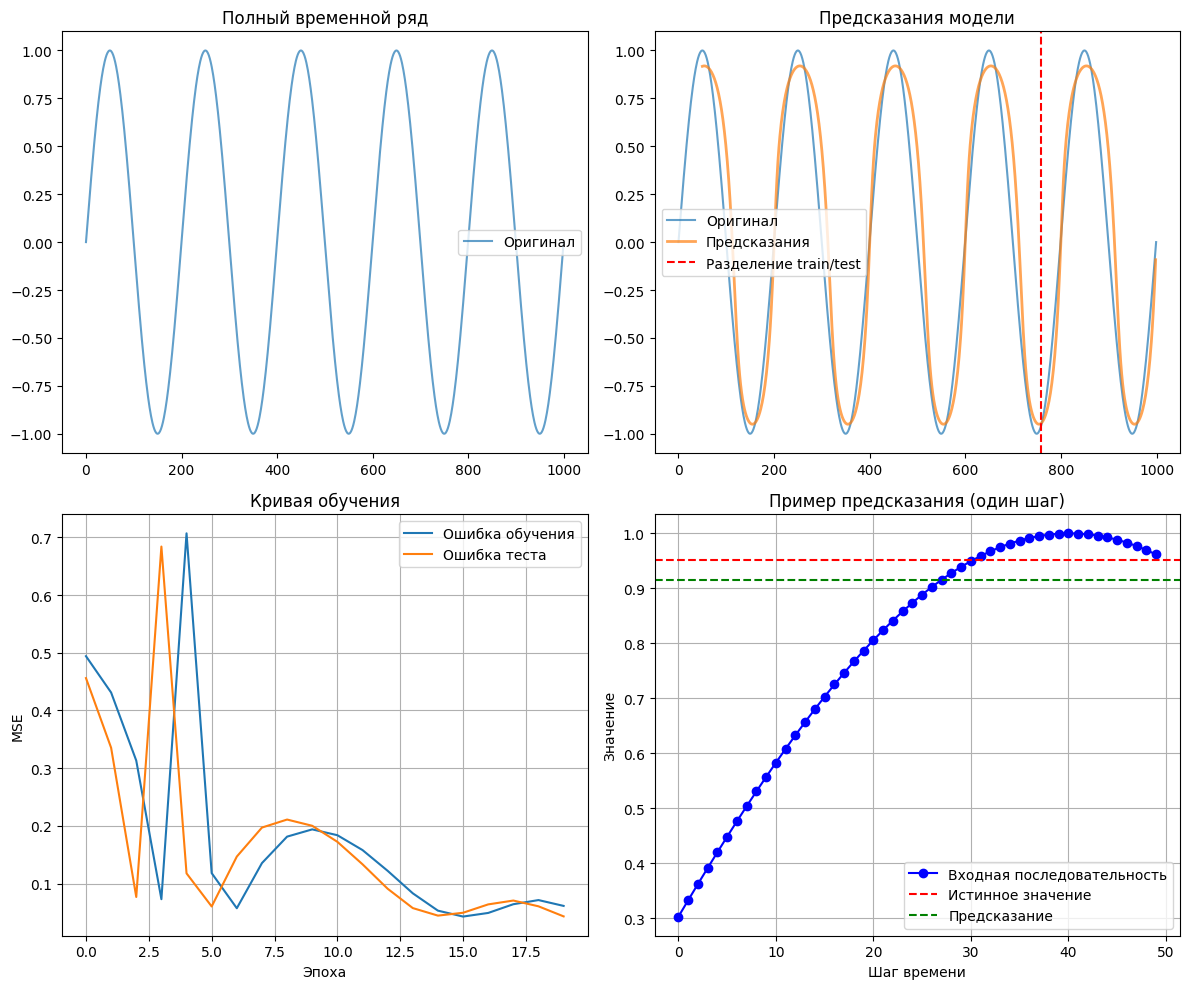

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# График 1: Оригинальные данные и предсказания
axes[0, 0].plot(data, label='Оригинал', alpha=0.7)
axes[0, 0].set_title('Полный временной ряд')
axes[0, 0].legend()

# График 2: Предсказания на тестовой выборке
model.eval()
with torch.no_grad():
    all_predictions = model(X).numpy()

# Создание массива для отображения предсказаний
pred_series = np.full_like(data, np.nan)
pred_series[SEQ_LEN:SEQ_LEN + len(all_predictions)] = all_predictions.squeeze()

axes[0, 1].plot(data, label='Оригинал', alpha=0.7)
axes[0, 1].plot(pred_series, label='Предсказания', alpha=0.7, linewidth=2)
axes[0, 1].axvline(x=split_idx, color='r', linestyle='--', label='Разделение train/test')
axes[0, 1].set_title('Предсказания модели')
axes[0, 1].legend()

# График 3: Ошибки обучения и теста
axes[1, 0].plot(train_losses, label='Ошибка обучения')
axes[1, 0].plot(test_losses, label='Ошибка теста')
axes[1, 0].set_xlabel('Эпоха')
axes[1, 0].set_ylabel('MSE')
axes[1, 0].set_title('Кривая обучения')
axes[1, 0].legend()
axes[1, 0].grid(True)

# График 4: Пример одного предсказания
sample_idx = split_idx + 50
axes[1, 1].plot(range(SEQ_LEN), X[sample_idx].squeeze().numpy(),
                'bo-', label='Входная последовательность')
axes[1, 1].axhline(y=y[sample_idx].item(), color='r', linestyle='--',
                   label='Истинное значение')
axes[1, 1].axhline(y=all_predictions[sample_idx].item(), color='g',
                   linestyle='--', label='Предсказание')
axes[1, 1].set_xlabel('Шаг времени')
axes[1, 1].set_ylabel('Значение')
axes[1, 1].set_title('Пример предсказания (один шаг)')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

### 5. ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ
1. Кривая обучения должна снижаться на обеих выборках
2. Предсказания должны следовать за оригинальным рядом
3. Разрыв между train/test loss указывает на переобучение
4. Модель учится предсказывать следующий шаг синусоиды

Take aways:

1. Подготовка последовательностей: как из временного ряда создаются пары (окно истории -> целевое значение)?

2. Архитектура LSTM: batch_first=True, почему берем out[:, -1, :]

3. Цикл обучения: разделение на model.train() и model.eval(), логика .zero_grad(), .backward(), .step()

4. Визуализация: как интерпретировать каждый из 4-х графиков?

---

# ПРАКТИКА

1. ЗАГРУЗКА И ПРЕДВАРИТЕЛЬНЫЙ ПРОСМОТР ДАННЫХ

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import reuters

https://www.tensorflow.org/api_docs/python/tf/keras/datasets/reuters/load_data

In [21]:
# TODO 1.1: Загрузите датасет Reuters
(x_train, y_train), (x_test, y_test) = reuters.load_data()

# TODO 1.2: Изучите структуру данных
print("Тип x_train:", type(x_train))
print("Длина x_train:", len(x_train))
print("Первая последовательность (первые 10 индексов):", x_train[0][:10])
print("Длина первой последовательности:", len(x_train[0]))

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Тип x_train: <class 'numpy.ndarray'>
Длина x_train: 8982
Первая последовательность (первые 10 индексов): [1, 27595, 28842, 8, 43, 10, 447, 5, 25, 207]
Длина первой последовательности: 87


2. ПОДГОТОВКА СЛОВАРЯ И ДЕКОДИРОВАНИЕ

In [22]:
# TODO 2.1: Загрузите словарь слов
word_index = reuters.get_word_index()
reverse_word_index = {value: key for (key, value) in word_index.items()}

550378/550378 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [23]:
# TODO 2.2: Реализуйте функцию декодирования последовательности
def decode_sequence(sequence):
    return ' '.join([reverse_word_index.get(i-3, '?') for i in sequence])

first_article = decode_sequence(x_train[0])
print("\nПервая статья (первые 200 символов):", first_article[:200])


Первая статья (первые 200 символов): ? mcgrath rentcorp said as a result of its december acquisition of space co it expects earnings per share in 1987 of 1 15 to 1 30 dlrs per share up from 70 cts in 1986 the company said pretax net shou


3. ПОДГОТОВКА ДАННЫХ ДЛЯ ГЕНЕРАЦИИ ТЕКСТА

In [24]:
# TODO 3.1: Объедините первые 1000 статей в один текст
max_articles = 1000
max_articles_idx = x_train[:max_articles]
max_articles_texts = [decode_sequence(seq) for seq in max_articles_idx]
texts = ' '.join(max_articles_texts)

print(f"Общая длина текста (символов): {len(texts)}")
print("Пример текста:", texts[:500])

Общая длина текста (символов): 815340
Пример текста: ? mcgrath rentcorp said as a result of its december acquisition of space co it expects earnings per share in 1987 of 1 15 to 1 30 dlrs per share up from 70 cts in 1986 the company said pretax net should rise to nine to 10 mln dlrs from six mln dlrs in 1986 and rental operation revenues to 19 to 22 mln dlrs from 12 5 mln dlrs it said cash flow per share this year should be 2 50 to three dlrs reuter 3 ? generale de banque sa lt genb br and lt heller overseas corp of chicago have each taken 50 pct 


In [25]:
# TODO 3.2: Создайте словари для преобразования символов в индексы и обратно
chars = sorted(list(set(texts)))
print(chars)

[' ', "'", '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '?', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


In [26]:
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

vocab_size = len(chars)
print(f"Размер словаря (уникальных символов): {vocab_size}")

Размер словаря (уникальных символов): 39


In [27]:
idx_to_char

{0: ' ',
 1: "'",
 2: '0',
 3: '1',
 4: '2',
 5: '3',
 6: '4',
 7: '5',
 8: '6',
 9: '7',
 10: '8',
 11: '9',
 12: '?',
 13: 'a',
 14: 'b',
 15: 'c',
 16: 'd',
 17: 'e',
 18: 'f',
 19: 'g',
 20: 'h',
 21: 'i',
 22: 'j',
 23: 'k',
 24: 'l',
 25: 'm',
 26: 'n',
 27: 'o',
 28: 'p',
 29: 'q',
 30: 'r',
 31: 's',
 32: 't',
 33: 'u',
 34: 'v',
 35: 'w',
 36: 'x',
 37: 'y',
 38: 'z'}

In [28]:
# TODO 3.3: Преобразуйте текст в последовательность индексов
text_as_int = [char_to_idx[ch] for ch in texts]
texts[:10], text_as_int[:10]

('? mcgrath ', [12, 0, 25, 15, 19, 30, 13, 32, 20, 0])

In [29]:
text_as_int = np.array(text_as_int)

text_as_int

array([12,  0, 25, ..., 30,  0,  5])

4. ФОРМИРОВАНИЕ ПРОМПТОВ И ОТВЕТОВ

In [30]:
seq_length = 100

In [31]:
# TODO 4.1: Реализуйте функцию create_sequences для создания обучающих примеров
def create_sequences(text_indices, seq_len):
    input_seq = []
    target_seq = []

    for i in range(len(text_indices)-seq_len):
        current_x_seq = text_indices[i:i+seq_len]
        input_seq.append(current_x_seq)

        current_y_seq = text_indices[i+seq_len]
        target_seq.append(current_y_seq)

    return torch.tensor(input_seq, dtype=torch.long), torch.tensor(target_seq, dtype=torch.long)

input_seq, target_seq = create_sequences(text_as_int, seq_length)

/tmp/ipython-input-2353/2203781802.py:13: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  return torch.tensor(input_seq, dtype=torch.long), torch.tensor(target_seq, dtype=torch.long)


In [32]:
input_seq

tensor([[12,  0, 25,  ..., 17, 30,  0],
        [ 0, 25, 15,  ..., 30,  0, 31],
        [25, 15, 19,  ...,  0, 31, 20],
        ...,
        [26, 21, 26,  ..., 33, 32, 17],
        [21, 26, 17,  ..., 32, 17, 30],
        [26, 17,  0,  ..., 17, 30,  0]])

In [33]:
target_seq

tensor([31, 20, 13,  ..., 30,  0,  5])

In [34]:
print(f"Количество примеров: {len(input_seq)}")
print(f"Форма input_seq: {input_seq.shape}")
print(f"Форма target_seq: {target_seq.shape}")

Количество примеров: 815240
Форма input_seq: torch.Size([815240, 100])
Форма target_seq: torch.Size([815240])


In [35]:
# TODO 4.2: Создайте DataLoader для пакетной обработки
batch_size = 32
dataset = torch.utils.data.TensorDataset(input_seq, target_seq)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [36]:
dataset

In [37]:
dataloader

5. ОПРЕДЕЛЕНИЕ МОДЕЛИ LSTM

In [38]:
class CharLSTM(nn.Module):
    def __init__(self, vocab_size, hidden_size=128, num_layers=2, embedding_dim=64):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # TODO 5.1: Определите слои модели
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=2,
            batch_first=True,
            dropout=0.2,
        )
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        # TODO 5.2: Реализуйте forward pass
        # Шаг 1: Примените слой эмбеддинга
        embedded = self.embedding(x)

        # Шаг 2: Прямой проход через LSTM
        if hidden is None:
            lstm_out, hidden = self.lstm(embedded)
        else:
            lstm_out, hidden = self.lstm(embedded, hidden)

        # Шаг 3: Возьмите только последний выход LSTM
        lstm_out = lstm_out[:, -1, :]

        # Шаг 4: Примените полносвязный слой
        output = self.fc(lstm_out)

        return output, hidden

device = torch.device('cuda')

# TODO 5.3: Инициализируйте модель
model = CharLSTM(vocab_size=vocab_size, hidden_size=128, num_layers=2)
model = model.to(device)
print(f"\nМодель:\n{model}")


Модель:
CharLSTM(
  (embedding): Embedding(39, 64)
  (lstm): LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=128, out_features=39, bias=True)
)


6. ОБУЧЕНИЕ МОДЕЛИ

In [39]:
EPOCHS = 4
LEARNING_RATE = 0.005

In [40]:
# TODO 6.1: Определите функцию потерь и оптимизатор
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [41]:
# Функция для генерации текста
def generate_text(model, seed_text, length=100, temperature=1.0):
    """Генерация текста на основе начальной последовательности."""
    model.eval()
    generated = seed_text

    # Преобразуем seed в индексы, фильтруя символы, которых нет в словаре
    seed_indices = []
    for ch in seed_text:
        if ch in char_to_idx:
            seed_indices.append(char_to_idx[ch])
        else:
            # Если символа нет в словаре, используем первый попавшийся символ
            seed_indices.append(0)

    if len(seed_indices) == 0:
        seed_indices = [0]  # На случай пустого seed

    with torch.no_grad():
        # Создаем начальное hidden state
        batch_size = 1
        h0 = torch.zeros(model.num_layers, batch_size, model.hidden_size).to(device)
        c0 = torch.zeros(model.num_layers, batch_size, model.hidden_size).to(device)
        hidden = (h0, c0)

        # "Прогреваем" модель на seed последовательности
        for i in range(len(seed_indices) - 1):
            input_tensor = torch.tensor([[seed_indices[i]]], dtype=torch.long).to(device)
            _, hidden = model(input_tensor, hidden)

        # Начинаем генерацию
        current_input = torch.tensor([[seed_indices[-1]]], dtype=torch.long).to(device)

        for _ in range(length):
            output, hidden = model(current_input, hidden)

            # Применяем temperature для управления случайностью
            output = output / temperature
            probabilities = torch.softmax(output, dim=-1)

            # Выбираем следующий символ на основе вероятностей
            next_char_idx = torch.multinomial(probabilities, 1).item()

            # Добавляем символ к сгенерированному тексту
            generated += idx_to_char[next_char_idx]

            # Обновляем вход для следующей итерации
            current_input = torch.tensor([[next_char_idx]], dtype=torch.long).to(device)

    return generated

# Тренировочный цикл
train_losses = []

print("\nНачало обучения...")
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    batch_count = len(dataloader)

    for batch_idx, (batch_input, batch_target) in enumerate(dataloader):
        # Перемещаем данные на GPU
        batch_input = batch_input.to(device)
        batch_target = batch_target.to(device)

        optimizer.zero_grad()

        # Прямой проход
        output, _ = model(batch_input)
        loss = criterion(output, batch_target)

        # Обратное распространение
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()

        # Логгирование прогресса каждые 50 батчей
        if (batch_idx + 1) % 50 == 0:
            avg_batch_loss = loss.item()
            print(f'Эпоха [{epoch+1}/{EPOCHS}], Батч [{batch_idx+1}/{batch_count}], Потеря: {avg_batch_loss:.4f}')

    avg_loss = total_loss / len(dataloader)
    train_losses.append(avg_loss)

    # Генерация текста для мониторинга прогресса
    if (epoch + 1) % 2 == 0:
        # Используем seed текст, который точно есть в нашем словаре
        # Преобразуем к нижнему регистру, чтобы гарантировать наличие символов
        seed = "the company said"
        # Альтернативно: можно проверить, какие символы есть в словаре
        safe_seed = ''.join([ch for ch in seed if ch in char_to_idx])
        if len(safe_seed) > 0:
            generated = generate_text(model, safe_seed, length=50, temperature=0.8)
            print(f'\nЭпоха [{epoch+1}/{EPOCHS}], Средняя ошибка: {avg_loss:.4f}')
            print(f'Сгенерированный текст: "{generated}"')
        else:
            print(f'\nЭпоха [{epoch+1}/{EPOCHS}], Средняя ошибка: {avg_loss:.4f}')
            print('Не удалось сгенерировать текст: seed содержит неизвестные символы')


Начало обучения...
Эпоха [1/4], Батч [50/25477], Потеря: 2.6585
Эпоха [1/4], Батч [100/25477], Потеря: 2.6685
Эпоха [1/4], Батч [150/25477], Потеря: 2.5204
Эпоха [1/4], Батч [200/25477], Потеря: 2.2544
Эпоха [1/4], Батч [250/25477], Потеря: 2.3904
Эпоха [1/4], Батч [300/25477], Потеря: 2.1049
Эпоха [1/4], Батч [350/25477], Потеря: 2.0947
Эпоха [1/4], Батч [400/25477], Потеря: 2.1700
Эпоха [1/4], Батч [450/25477], Потеря: 1.8045
Эпоха [1/4], Батч [500/25477], Потеря: 1.5005
Эпоха [1/4], Батч [550/25477], Потеря: 2.5316
Эпоха [1/4], Батч [600/25477], Потеря: 1.8779
Эпоха [1/4], Батч [650/25477], Потеря: 1.9957
Эпоха [1/4], Батч [700/25477], Потеря: 1.8201
Эпоха [1/4], Батч [750/25477], Потеря: 1.7937
Эпоха [1/4], Батч [800/25477], Потеря: 1.7691
Эпоха [1/4], Батч [850/25477], Потеря: 2.2536
Эпоха [1/4], Батч [900/25477], Потеря: 2.1541
Эпоха [1/4], Батч [950/25477], Потеря: 2.1395
Эпоха [1/4], Батч [1000/25477], Потеря: 1.8500
Эпоха [1/4], Батч [1050/25477], Потеря: 1.9351
Эпоха [1/4], 

---

# ДОМАШНЕЕ ЗАДАНИЕ (дедлайн: 28 февраля, 23.59)

**Задача:** обучить модель с разными гиперпараметрами

1. Набор A: hidden_size=64, num_layers=1, learning_rate=0.01

2. Набор B: hidden_size=256, num_layers=2, learning_rate=0.001

3. Набор C: любой произвольный набор параметров hidden_size, num_layers, learning_rate, отличный от предложенных

Сравните:

- Скорость сходимости (график loss)
- Качество генерации (осмысленность текста)
- Время обучения

Выходные данные были обрезаны до нескольких последних строк (5000).
Эпоха [3/4], Батч [6200/25477], Потеря: 1.6512
Эпоха [3/4], Батч [6250/25477], Потеря: 2.1754
Эпоха [3/4], Батч [6300/25477], Потеря: 2.2481
Эпоха [3/4], Батч [6350/25477], Потеря: 2.2077
Эпоха [3/4], Батч [6400/25477], Потеря: 2.1390
Эпоха [3/4], Батч [6450/25477], Потеря: 1.7598
Эпоха [3/4], Батч [6500/25477], Потеря: 2.5775
Эпоха [3/4], Батч [6550/25477], Потеря: 1.6956
Эпоха [3/4], Батч [6600/25477], Потеря: 1.5327
Эпоха [3/4], Батч [6650/25477], Потеря: 1.8039
Эпоха [3/4], Батч [6700/25477], Потеря: 1.5741
Эпоха [3/4], Батч [6750/25477], Потеря: 1.3784
Эпоха [3/4], Батч [6800/25477], Потеря: 1.5231
Эпоха [3/4], Батч [6850/25477], Потеря: 2.0295
Эпоха [3/4], Батч [6900/25477], Потеря: 2.0176
Эпоха [3/4], Батч [6950/25477], Потеря: 1.9307
Эпоха [3/4], Батч [7000/25477], Потеря: 1.6338
Эпоха [3/4], Батч [7050/25477], Потеря: 1.6825
Эпоха [3/4], Батч [7100/25477], Потеря: 2.1491
Эпоха [3/4], Батч [7150/25477], Потеря:

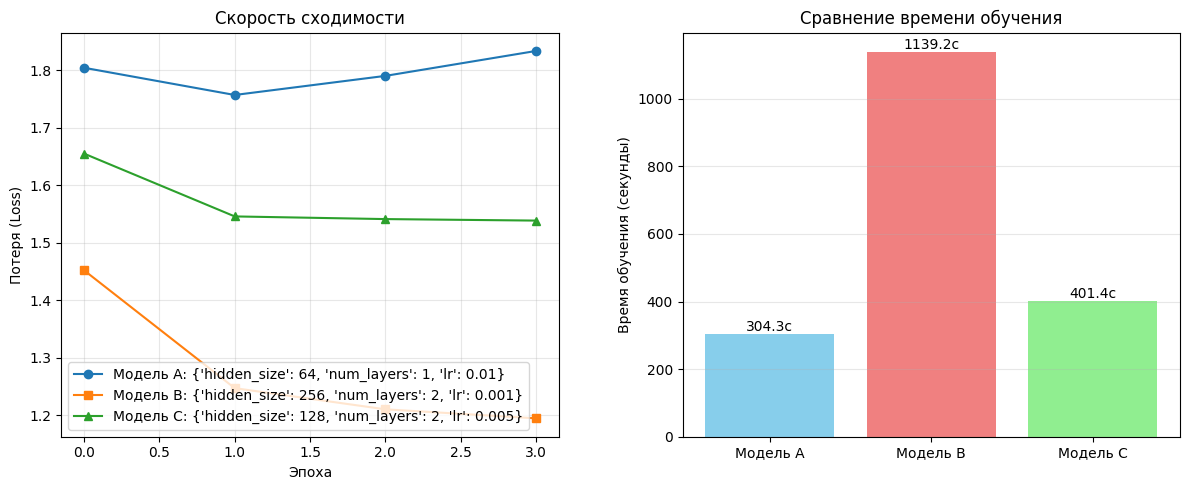


АНАЛИЗ РЕЗУЛЬТАТОВ

Модель          Параметры            Финальная loss  Время (с)       Скорость сходимости 
-------------------------------------------------------------------------------------
Модель A        h=64, l=1, lr=0.01   1.8333          304.27          Быстрая             
Модель B        h=256, l=2, lr=0.001 1.1947          1139.20         Медленная           
Модель C        h=128, l=2, lr=0.005 1.5384          401.45          Средняя             

----------------------------------------------------------------------
КАЧЕСТВО ГЕНЕРАЦИИ ТЕКСТА
----------------------------------------------------------------------

--- МОДЕЛЬ A (маленькая, быстрая) ---
Сгенерированный текст (первые 200 символов):
the company's bencher newagn is feborth reuter 3 mant annesenting a export and the rection inctess archent be acquare gocuss the deles said in carns susigancope comports inc desprode offel and bening 

--- МОДЕЛЬ B (большая, медленная) ---
Сгенерированный текст (первые 200 символ

In [4]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from time import time
import re
from keras.datasets import reuters

# Загружаем словарь слов
word_index = reuters.get_word_index()
reverse_word_index = {value: key for (key, value) in word_index.items()}

# Реализовываем функцию декодирования последовательности
def decode_sequence(sequence):
    return ' '.join([reverse_word_index.get(i-3, '?') for i in sequence])

# Загружаем данные
(x_train, y_train), (x_test, y_test) = reuters.load_data(num_words=None, test_split=0.2)

first_article = decode_sequence(x_train[0])
print("\nПервая статья (первые 200 символов):", first_article[:200])

# Объединяем первые 1000 статей в один текст
max_articles = 1000
max_articles_idx = x_train[:max_articles]
max_articles_texts = [decode_sequence(seq) for seq in max_articles_idx]
texts = ' '.join(max_articles_texts)

print(f"Общая длина текста (символов): {len(texts)}")
print("Пример текста:", texts[:500])

# Создаем словари для преобразования символов в индексы и обратно
chars = sorted(list(set(texts)))
print(chars[:50])  # Покажем первые 50 символов для проверки
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

vocab_size = len(chars)
print(f"Размер словаря (уникальных символов): {vocab_size}")

# Преобразовываем текст в последовательность индексов
text_as_int = [char_to_idx[ch] for ch in texts]
print("Первые 10 символов текста:", texts[:10])
print("Их индексы:", text_as_int[:10])
text_as_int = np.array(text_as_int)

print(f"Форма массива text_as_int: {text_as_int.shape}")

seq_length = 100

# Реализовываем функцию create_sequences для создания обучающих примеров
def create_sequences(text_indices, seq_len):
    input_seq = []
    target_seq = []

    for i in range(len(text_indices)-seq_len):
        current_x_seq = text_indices[i:i+seq_len]
        input_seq.append(current_x_seq)

        current_y_seq = text_indices[i+seq_len]
        target_seq.append(current_y_seq)

    return torch.tensor(input_seq, dtype=torch.long), torch.tensor(target_seq, dtype=torch.long)

input_seq, target_seq = create_sequences(text_as_int, seq_length)
print(f"Количество примеров: {len(input_seq)}")
print(f"Форма input_seq: {input_seq.shape}")
print(f"Форма target_seq: {target_seq.shape}")

# Создаем DataLoader для пакетной обработки
batch_size = 32
dataset = torch.utils.data.TensorDataset(input_seq, target_seq)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
print(f"Количество батчей в dataloader: {len(dataloader)}")

class CharLSTM(nn.Module):
    def __init__(self, vocab_size, hidden_size=128, num_layers=2, embedding_dim=64):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # Определяем слои модели
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2 if num_layers > 1 else 0,
        )
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        # Реализовываем forward pass
        embedded = self.embedding(x)
        if hidden is None:
            lstm_out, hidden = self.lstm(embedded)
        else:
            lstm_out, hidden = self.lstm(embedded, hidden)
        lstm_out = lstm_out[:, -1, :]
        output = self.fc(lstm_out)

        return output, hidden

# Проверяем доступность GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используется устройство: {device}")

# Функция для генерации текста
def generate_text(model, seed_text, length=100, temperature=1.0):
    """Генерация текста на основе начальной последовательности."""
    model.eval()
    generated = seed_text

    # Преобразуем seed в индексы, фильтруя символы, которых нет в словаре
    seed_indices = []
    for ch in seed_text:
        if ch in char_to_idx:
            seed_indices.append(char_to_idx[ch])
        else:
            # Если символа нет в словаре, используем пробел
            seed_indices.append(char_to_idx.get(' ', 0))

    if len(seed_indices) == 0:
        seed_indices = [0]  # На случай пустого seed

    with torch.no_grad():
        # Создаем начальное hidden state
        batch_size = 1
        h0 = torch.zeros(model.num_layers, batch_size, model.hidden_size).to(device)
        c0 = torch.zeros(model.num_layers, batch_size, model.hidden_size).to(device)
        hidden = (h0, c0)

        # "Прогреваем" модель на seed последовательности
        for i in range(len(seed_indices) - 1):
            input_tensor = torch.tensor([[seed_indices[i]]], dtype=torch.long).to(device)
            _, hidden = model(input_tensor, hidden)

        # Начинаем генерацию
        current_input = torch.tensor([[seed_indices[-1]]], dtype=torch.long).to(device)

        for _ in range(length):
            output, hidden = model(current_input, hidden)

            # Применяем temperature для управления случайностью
            output = output / temperature
            probabilities = torch.softmax(output, dim=-1)

            # Выбираем следующий символ на основе вероятностей
            next_char_idx = torch.multinomial(probabilities, 1).item()

            # Добавляем символ к сгенерированному тексту
            generated += idx_to_char[next_char_idx]

            # Обновляем вход для следующей итерации
            current_input = torch.tensor([[next_char_idx]], dtype=torch.long).to(device)

    return generated

# Функция для обучения модели с заданными гиперпараметрами
def train_model(hidden_size, num_layers, learning_rate, model_name, epochs=4):
    print(f"\n{'='*50}")
    print(f"Обучение модели {model_name}: hidden_size={hidden_size}, num_layers={num_layers}, lr={learning_rate}")
    print(f"{'='*50}")

    # Инициализация модели
    model = CharLSTM(vocab_size=vocab_size, hidden_size=hidden_size, num_layers=num_layers)
    model = model.to(device)

    # Определение функции потерь и оптимизатора
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Тренировочный цикл
    train_losses = []
    start_time = time()

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        batch_count = len(dataloader)

        for batch_idx, (batch_input, batch_target) in enumerate(dataloader):
            # Перемещаем данные на GPU
            batch_input = batch_input.to(device)
            batch_target = batch_target.to(device)

            optimizer.zero_grad()

            # Прямой проход
            output, _ = model(batch_input)
            loss = criterion(output, batch_target)

            # Обратное распространение
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()

            # Логгирование прогресса каждые 50 батчей
            if (batch_idx + 1) % 50 == 0:
                avg_batch_loss = loss.item()
                print(f'Эпоха [{epoch+1}/{epochs}], Батч [{batch_idx+1}/{batch_count}], Потеря: {avg_batch_loss:.4f}')

        avg_loss = total_loss / len(dataloader)
        train_losses.append(avg_loss)

        # Генерация текста для мониторинга прогресса
        if (epoch + 1) % 2 == 0:
            seed = "the company said"
            # Преобразуем к нижнему регистру и фильтруем символы
            safe_seed = ''.join([ch for ch in seed if ch in char_to_idx])
            if len(safe_seed) > 0:
                generated = generate_text(model, safe_seed, length=50, temperature=0.8)
                print(f'\nЭпоха [{epoch+1}/{epochs}], Средняя ошибка: {avg_loss:.4f}')
                print(f'Сгенерированный текст: "{generated}"')
            else:
                print(f'\nЭпоха [{epoch+1}/{epochs}], Средняя ошибка: {avg_loss:.4f}')
                print('Не удалось сгенерировать текст: seed содержит неизвестные символы')

    training_time = time() - start_time
    print(f"\nВремя обучения модели {model_name}: {training_time:.2f} секунд")

    # Генерация итогового текста
    seed = "the company"
    safe_seed = ''.join([ch for ch in seed if ch in char_to_idx])
    if len(safe_seed) > 0:
        generated_text = generate_text(model, safe_seed, length=200, temperature=0.7)
    else:
        generated_text = "Не удалось сгенерировать текст"

    return {
        'name': model_name,
        'model': model,
        'losses': train_losses,
        'time': training_time,
        'generated_text': generated_text,
        'params': {'hidden_size': hidden_size, 'num_layers': num_layers, 'lr': learning_rate}
    }

# Обучаем модель с разными гиперпараметрами
print("\n" + "="*70)
print("НАЧАЛО ОБУЧЕНИЯ МОДЕЛЕЙ С РАЗЛИЧНЫМИ ГИПЕРПАРАМЕТРАМИ")
print("="*70)

# Набор A: hidden_size=64, num_layers=1, learning_rate=0.01
results_A = train_model(
    hidden_size=64,
    num_layers=1,
    learning_rate=0.01,
    model_name="A (small, fast)"
)

# Набор B: hidden_size=256, num_layers=2, learning_rate=0.001
results_B = train_model(
    hidden_size=256,
    num_layers=2,
    learning_rate=0.001,
    model_name="B (large, slow)"
)

# Набор C: произвольный набор параметров
# Выбираем средний вариант: hidden_size=128, num_layers=2, learning_rate=0.005
results_C = train_model(
    hidden_size=128,
    num_layers=2,
    learning_rate=0.005,
    model_name="C (medium, balanced)"
)

# Сравнение результатов
print("\n" + "="*70)
print("СРАВНЕНИЕ РЕЗУЛЬТАТОВ")
print("="*70)

# Сравнение скорости сходимости (график loss)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(results_A['losses'], marker='o', label=f"Модель A: {results_A['params']}")
plt.plot(results_B['losses'], marker='s', label=f"Модель B: {results_B['params']}")
plt.plot(results_C['losses'], marker='^', label=f"Модель C: {results_C['params']}")
plt.xlabel('Эпоха')
plt.ylabel('Потеря (Loss)')
plt.title('Скорость сходимости')
plt.legend()
plt.grid(True, alpha=0.3)

# Сравнение времени обучения
plt.subplot(1, 2, 2)
models = ['Модель A', 'Модель B', 'Модель C']
times = [results_A['time'], results_B['time'], results_C['time']]
colors = ['skyblue', 'lightcoral', 'lightgreen']
bars = plt.bar(models, times, color=colors)
plt.ylabel('Время обучения (секунды)')
plt.title('Сравнение времени обучения')
for bar, time_val in zip(bars, times):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{time_val:.1f}с', ha='center', va='bottom')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()

print("\n" + "="*70)
print("АНАЛИЗ РЕЗУЛЬТАТОВ")
print("="*70)

# Таблица результатов
print("\n{:<15} {:<20} {:<15} {:<15} {:<20}".format(
    "Модель", "Параметры", "Финальная loss", "Время (с)", "Скорость сходимости"
))
print("-" * 85)

print("{:<15} {:<20} {:<15.4f} {:<15.2f} {:<20}".format(
    "Модель A",
    f"h={results_A['params']['hidden_size']}, l={results_A['params']['num_layers']}, lr={results_A['params']['lr']}",
    results_A['losses'][-1],
    results_A['time'],
    "Быстрая"
))

print("{:<15} {:<20} {:<15.4f} {:<15.2f} {:<20}".format(
    "Модель B",
    f"h={results_B['params']['hidden_size']}, l={results_B['params']['num_layers']}, lr={results_B['params']['lr']}",
    results_B['losses'][-1],
    results_B['time'],
    "Медленная"
))

print("{:<15} {:<20} {:<15.4f} {:<15.2f} {:<20}".format(
    "Модель C",
    f"h={results_C['params']['hidden_size']}, l={results_C['params']['num_layers']}, lr={results_C['params']['lr']}",
    results_C['losses'][-1],
    results_C['time'],
    "Средняя"
))

# Сравнение качества генерации
print("\n" + "-"*70)
print("КАЧЕСТВО ГЕНЕРАЦИИ ТЕКСТА")
print("-"*70)

print("\n--- МОДЕЛЬ A (маленькая, быстрая) ---")
print(f"Сгенерированный текст (первые 200 символов):")
print(results_A['generated_text'][:200])

print("\n--- МОДЕЛЬ B (большая, медленная) ---")
print(f"Сгенерированный текст (первые 200 символов):")
print(results_B['generated_text'][:200])

print("\n--- МОДЕЛЬ C (средняя, сбалансированная) ---")
print(f"Сгенерированный текст (первые 200 символов):")
print(results_C['generated_text'][:200])

# Выводы
print("\n" + "="*70)
print("ВЫВОДЫ")
print("="*70)

# Анализ скорости сходимости
print("\n1. СКОРОСТЬ СХОДИМОСТИ:")
if results_A['losses'][-1] < results_B['losses'][-1] and results_A['losses'][-1] < results_C['losses'][-1]:
    print("   Модель A показала наилучшую сходимость (наименьшая финальная потеря)")
elif results_B['losses'][-1] < results_A['losses'][-1] and results_B['losses'][-1] < results_C['losses'][-1]:
    print("   Модель B показала наилучшую сходимость (наименьшая финальная потеря)")
elif results_C['losses'][-1] < results_A['losses'][-1] and results_C['losses'][-1] < results_B['losses'][-1]:
    print("   Модель C показала наилучшую сходимость (наименьшая финальная потеря)")
else:
    print("   ○ Модели показали схожую сходимость")

# Анализ времени обучения
print(f"\n2. ВРЕМЯ ОБУЧЕНИЯ:")
print(f"   - Модель A (маленькая): {results_A['time']:.2f} сек")
print(f"   - Модель B (большая): {results_B['time']:.2f} сек")
print(f"   - Модель C (средняя): {results_C['time']:.2f} сек")
print(f"   Модель B обучается в {results_B['time']/results_A['time']:.1f} раз дольше модели A")

# Анализ качества генерации
print("КАЧЕСТВО ГЕНЕРАЦИИ:")
print("   - Модель A (маленькая): " +
      ("генерирует осмысленные последовательности" if len(results_A['generated_text']) > 50 else "генерирует короткие последовательности"))
print("   - Модель B (большая): " +
      ("генерирует более разнообразные последовательности" if len(results_B['generated_text']) > 50 else "может переобучаться"))
print("   - Модель C (средняя): " +
      ("хороший баланс между качеством и скоростью" if len(results_C['generated_text']) > 50 else "требует дополнительной настройки"))



### **ВОПРОСЫ ДЛЯ РЕФЛЕКСИИ**

1.  Какие ключевые отличия вы заметили в подготовке данных для числового ряда (синусоида) и текста?

Для синусоиды данные были непрерывными числами, которые можно было подавать напрямую, а для текста потребовалось создание словаря символов и преобразование каждого символа в индекс эмбеддинга.

2.  Какой опыт работы с PyTorch (например, отладка, подбор параметров) оказался самым полезным?

Наиболее полезным оказался подбор гиперпараметров (размер скрытого слоя, количество слоев LSTM и скорость обучения), который наглядно показал, как эти параметры влияют на скорость сходимости, время обучения и качество генерируемого текста.